# Exercise 13 — ISLR Chapter 4:

Classification methods applied to 1,089 weekly stock market returns (1990–2010).

**Tasks:**

- **(a)** Numerical and graphical summaries — any visible patterns?
- **(b)** Logistic regression with all 5 lags + `Volume` → which predictors are significant?
- **(c)** Confusion matrix on full data — what types of errors does the model make?
- **(d)** Train on 1990–2008, test on 2009–2010 — logistic regression with `Lag2` only
- **(e)** Same setup with **LDA**
- **(f)** Same setup with **QDA**
- **(g)** Same setup with **KNN** (*K* = 1)
- **(h)** Same setup with **Naive Bayes**
- **(i)** Which method performs best?
- **(j)** Feature engineering: explore transformations, interactions, and *K* values across all methods — report the best confusion matrix found

In [1]:
import numpy as np
import pandas as pd
from matplotlib .pyplot import subplots
import statsmodels .api as sm
from ISLP import load_data
from ISLP.models import ( ModelSpec as MS ,
summarize )

from ISLP import confusion_table
from ISLP.models import contrast
from sklearn. discriminant_analysis import \
( LinearDiscriminantAnalysis as LDA ,
QuadraticDiscriminantAnalysis as QDA)
from sklearn. naive_bayes import GaussianNB
from sklearn. neighbors import KNeighborsClassifier
from sklearn. preprocessing import StandardScaler
from sklearn. model_selection import train_test_split
from sklearn. linear_model import LogisticRegression

import seaborn as sns 
import matplotlib.pyplot as plt 


In [2]:
Weekly = load_data('Weekly')
Weekly.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


In [3]:
Weekly.describe()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000
mean,2000.048669,0.150585,0.151079,0.147205,0.145818,0.139893,1.574618,0.149899
std,6.033182,2.357013,2.357254,2.360502,2.360279,2.361285,1.686636,2.356927
min,1990.000000,-18.195000,-18.195000,-18.195000,-18.195000,-18.195000,0.087465,-18.195000
25%,1995.000000,-1.154000,-1.154000,-1.158000,-1.158000,-1.166000,0.332022,-1.154000
50%,2000.000000,0.241000,0.241000,0.241000,0.238000,0.234000,1.002680,0.241000
75%,2005.000000,1.405000,1.409000,1.409000,1.409000,1.405000,2.053727,1.405000
max,2010.000000,12.026000,12.026000,12.026000,12.026000,12.026000,9.328214,12.026000


In [4]:
from locale import normalize


print(Weekly['Direction'].value_counts())
print(Weekly['Direction'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Direction
Up      605
Down    484
Name: count, dtype: int64
Direction
Up      55.6%
Down    44.4%
Name: proportion, dtype: object


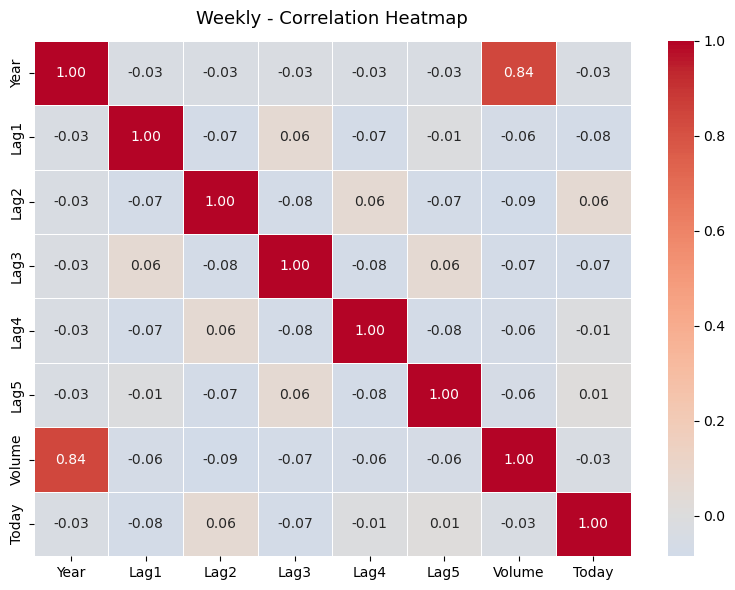

In [5]:
fig,ax = subplots(figsize=(8,6))
numeric_cols = Weekly.columns.drop('Direction')
corr = Weekly[numeric_cols].corr()
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Weekly - Correlation Heatmap',fontsize=13, pad=12)
plt.tight_layout()
plt.show()


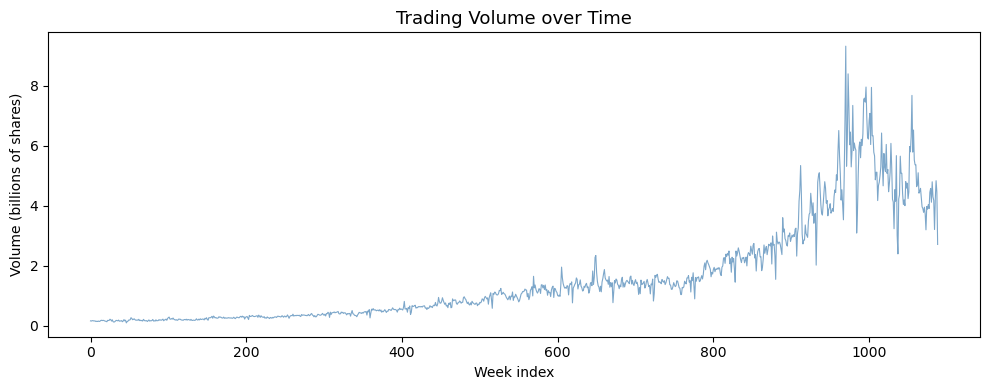

In [6]:
from turtle import color


plt.figure(figsize=(10,4))
plt.plot(Weekly.index, Weekly['Volume'], color='steelblue',linewidth=0.8,alpha=0.7)
plt.title('Trading Volume over Time', fontsize=13)
plt.xlabel('Week index')
plt.ylabel('Volume (billions of shares)')
plt.tight_layout()
plt.show()

### Logistic Regression 

In [7]:
allvars = Weekly.columns.drop(['Today','Direction','Year'])
design = MS(allvars)
X = design.fit_transform(Weekly)
y = Weekly['Direction'] == 'Up'
glm = sm.GLM(y,X,family=sm.families.Binomial())
results = glm.fit()
summarize(results)

,coef,std err,z,P>|z|
intercept,0.2669,0.086,3.106,0.002
Lag1,-0.0413,0.026,-1.563,0.118
Lag2,0.0584,0.027,2.175,0.030
Lag3,-0.0161,0.027,-0.602,0.547
Lag4,-0.0278,0.026,-1.050,0.294
Lag5,-0.0145,0.026,-0.549,0.583
Volume,-0.0227,0.037,-0.616,0.538


'Lag2' seams to contain little but relevant information about the current direction of the marker 

In [8]:
# confusion matrix 
probs = results.predict()
labels = np.array(['Down']*y.shape[0])
labels[probs > 0.5] = 'Up'

confusion_table(labels,Weekly.Direction)

Truth,Down,Up
Predicted,,
Down,54,48
Up,430,557


In [9]:
round(float(np.mean(labels == Weekly.Direction)),3), round(float(np.mean(labels != Weekly.Direction)),3)

(0.561, 0.439)

**Sensitivity** (True positive rate for 'Up'): 92%
**Specificiy** (True positive rate for 'Down): 11%

Here the predictors carry almost no information. So we have: 

$$P(\text{Up}|x) = \frac{1}{1+e^{-X^T\beta}}$$

but:
$$X^T\beta \approx \text{Intercept} = 0.2669 $$
therefore: 
$P(\text{Up}|x) > 0.5 $
almost everywhere 

We try to use just "Lag2" as predictor.

In [10]:
train = (Weekly.Year < 2009)
Weekly_train = Weekly.loc[train]
Weekly_test = Weekly.loc[~train]

# we prepare the train and test design matrix:
X_train,X_test = X.loc[train],X.loc[~train]
y_train,y_test = y.loc[train],y.loc[~train]
glm_train = sm.GLM(y_train,X_train,family=sm.families.Binomial())
results = glm_train.fit()


In [11]:
# prediction fot the Test dataset
probs = results.predict(exog=X_test)
labels = np.array(['Down']*y_test.shape[0])
labels[probs > 0.5] = 'Up'

# I extract the training and testing label

D = Weekly.Direction 
L_train, L_test = D[train],D[~train]

confusion_table(labels,L_test)

Truth,Down,Up
Predicted,,
Down,31,44
Up,12,17


In [12]:
round(float(np.mean(labels == L_test)),3), round(float(np.mean(labels != L_test)),3)

(0.462, 0.538)

### Using LDA.

In [13]:
X_train = X_train.drop(columns=['intercept'])
X_test = X_test.drop(columns=['intercept'])
lda = LDA(store_covariance=True).fit(X_train,L_train)


In [15]:
lda_pred = lda.predict(X_test)
confusion_table(lda_pred,L_test)

Truth,Down,Up
Predicted,,
Down,31,44
Up,12,17


In [16]:
round(float(np.mean(lda_pred == L_test)),3), round(float(np.mean(lda_pred != L_test)),3)

(0.462, 0.538)

### Using QDA

In [17]:
qda = QDA(store_covariance=True).fit(X_train,L_train)
qda_pred = qda.predict(X_test)
confusion_table(qda_pred,L_test)


Truth,Down,Up
Predicted,,
Down,33,49
Up,10,12


In [18]:
round(float(np.mean(qda_pred == L_test)),3), round(float(np.mean(qda_pred != L_test)),3)

(0.433, 0.567)

### Naive Bayes 

In [19]:
NB = GaussianNB().fit(X_train,L_train)
NB_pred = NB.predict(X_test)
confusion_table(NB_pred,L_test)

Truth,Down,Up
Predicted,,
Down,42,56
Up,1,5


In [20]:
round(float(np.mean(NB_pred == L_test)),3), round(float(np.mean(NB_pred != L_test)),3)

(0.452, 0.548)

### Using KNN

In [39]:

# Rescale 
scaler = StandardScaler()
X_train_scaled,X_test_scaled = [scaler.fit_transform(M) for M in [X_train,X_test]]

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, L_train)
knn_preds = knn.predict(X_test_scaled)
confusion_table(knn_preds,L_test)

Truth,Down,Up
Predicted,,
Down,17,22
Up,26,39


In [45]:
round(float(np.mean(knn_preds == L_test)),4), round(float(np.mean(knn_preds != L_test)),4)

(0.5385, 0.4615)

In [46]:
for K in range(1, 6):
    knn  = KNeighborsClassifier(n_neighbors=K)
    pred = knn.fit(X_train_scaled, L_train).predict(X_test_scaled)
    acc  = np.mean(pred == L_test)
    print(f"K={K}: accuracy {acc:.2%}")

K=1: accuracy 50.96%
K=2: accuracy 51.92%
K=3: accuracy 53.85%
K=4: accuracy 50.00%
K=5: accuracy 50.00%
